# PyPSA-DE Network Analysis


In [44]:
import os
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
import warnings, yaml, pathlib
from matplotlib import cm

# ── Fix GDAL/cartopy data path ──────────────────────────────
import cartopy
gdal_data = os.path.join(os.path.dirname(cartopy.__file__), "data")
if os.path.exists(gdal_data):
    os.environ["GDAL_DATA"] = gdal_data

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
%matplotlib inline

## 0 — Configuration

In [12]:
# ── Networks ────────────────────────────────────────────────────
# Point each nw_* at a solved .nc file. Running this cell loads them all,
# once. In any analysis cell below, choose one with:  analyzed_nw = nw_...
# To add a network, add one  nw_x = load(ROOT / r"...")  line.
ROOT = pathlib.Path(r"C:\repos\pypsa-de")  # devcloud: r"e:\23-06-13_localCode\FiBe\pypsa-de"

# ── Shared, network-independent setup (plotting colours + map) ──
import re
import geopandas as gpd
with open(ROOT / "config" / "plotting.default.yaml") as f:
    plot_cfg = yaml.safe_load(f)["plotting"]
with open(ROOT / "config" / "config.de.yaml") as f:
    de_cfg = yaml.safe_load(f)
tech_colors = {**plot_cfg.get("tech_colors", {}), **de_cfg.get("plotting", {}).get("tech_colors", {})}
proj = ccrs.EqualEarth()
DE_BOUNDS = [5.5, 15.5, 47.0, 55.5]  # lon_min, lon_max, lat_min, lat_max


def load(path):
    """Read a solved network and derive everything the cells below need.

    Returns a dict of ready-to-use objects. An analysis cell picks a network
    with  analyzed_nw = nw_...  and unpacks it with  globals().update(analyzed_nw),
    then uses n, sw, de_buses, TITLE, ... directly. Every shared per-network
    quantity is computed here, once, so each analysis cell is self-contained.
    """
    p = pathlib.Path(path)
    n = pypsa.Network(str(p))

    # Metadata straight off the file path (pypsa-de naming convention):
    #   results/<run>/<scenario>/networks/base_s_<clusters>__none_<year>.nc  (our runs)
    #   results/<run>/base_s_<clusters>_..._<year>.nc                        (flat, e.g. Ariadne)
    clusters = int(re.search(r"base_s_(\d+)", p.stem).group(1))
    year = int(re.search(r"(20\d{2})", p.stem).group(1))   # 4-digit horizon; tolerates _op etc.
    if "networks" in p.parts:
        i = p.parts.index("networks")
        scenario, run = p.parts[i - 1], p.parts[i - 2]
    else:
        scenario, run = None, p.parent.name
    label = f"{run} / {scenario}" if scenario else run

    # ── Bus / component index sets ────────────────────────────────
    de_buses = n.buses.query("country == 'DE' and carrier == 'AC'").index
    de_all_buses = n.buses.query("country == 'DE'").index
    de_lv_buses = n.buses.query("country == 'DE' and carrier == 'low voltage'").index
    # Map any sub-bus (battery, low-voltage, ...) back to its AC parent so
    # sector-coupled quantities can be summed per cluster.
    loc = n.buses["location"] if "location" in n.buses.columns else pd.Series(dtype=object)
    bus_to_ac = loc.reindex(n.buses.index)
    bus_to_ac = bus_to_ac.where(bus_to_ac.notna(), pd.Series(n.buses.index, index=n.buses.index))

    # ── Derived selections shared by several cells ────────────────
    sw = n.snapshot_weightings.generators
    elec_loads = n.loads[n.loads.bus.isin(de_lv_buses) & (n.loads.carrier == "electricity")]
    load_per_bus = (
        n.loads_t.p_set[elec_loads.index].multiply(sw, axis=0).sum()
        .groupby(elec_loads.bus.map(bus_to_ac)).sum() / 1e6
    )  # TWh of direct electricity demand per AC bus
    _excl = {"DC", "battery charger", "battery discharger", "home battery charger",
             "home battery discharger", "electricity distribution grid"}
    link_gen_links = n.links[
        n.links.bus1.isin(de_buses)
        & ~n.links.carrier.isin(_excl)
        & ~n.links.index.str.endswith("-reversed")
    ]  # links delivering power into DE AC buses (CHPs, CCGTs, H2 turbines, ...)

    regions_path = ROOT / "resources" / f"regions_onshore_base_s_{clusters}.geojson"
    if regions_path.exists():
        regions = gpd.read_file(regions_path)
    else:
        print(f"  (no regions file for {clusters} clusters — map cells will have no zones)")
        regions = gpd.GeoDataFrame(columns=["name", "geometry"], geometry="geometry")

    print(f"loaded  {label}  ({year})  —  {len(n.buses)} buses, "
          f"{len(de_buses)} DE AC buses, {len(n.snapshots)} snapshots")

    return dict(
        n=n,
        LABEL=label, SCENARIO=scenario, CLUSTERS=clusters, YEAR=year,
        TITLE=f"{label}  ({year})",          # <- put this in every plot title
        sw=sw,
        de_buses=de_buses, de_all_buses=de_all_buses, de_lv_buses=de_lv_buses,
        de_gens=n.generators[n.generators.bus.isin(de_buses)].index,
        de_sus=n.storage_units[n.storage_units.bus.isin(de_buses)].index,
        ac_buses=n.buses[n.buses.carrier == "AC"],
        bus_to_ac=bus_to_ac,
        elec_loads=elec_loads,
        link_gen_links=link_gen_links,
        load_per_bus=load_per_bus,
        regions=regions,
        de_regions=regions[regions.name.isin(de_buses)],
    )




In [58]:
#nw_default_2035 = load(ROOT / r"results\default4712SS\KN2045_Mix\networks\base_s_27__none_2035.nc")
#nw_default_2030 = load(ROOT / r"results\default4712SS\KN2045_Mix\networks\base_s_27__none_2030.nc")
#nw_test_fixedcap_2035 = load(ROOT / r"results\test02_fixedcap\KN2045_Mix\networks\base_s_27__none_2035_op.nc")
#nw_fixedcap_2035 = load(ROOT / r"results\default4712SS_fixedcap\KN2045_Mix\networks\base_s_27__none_2035_op.nc")
#nw_test02_custom_map_2035 = load(ROOT / r"results\test02_custom_map\KN2045_Mix\networks\base_s_27__none_2035.nc")
#nw_default8760 = load(ROOT / r"results\default8760SS\KN2045_Mix\networks\base_s_27__none_2035.nc")

nw_ariadne_2035 = load(ROOT / r"results\ariadne_technologiemix\base_s_49_lvopt__none_2035.nc")
#nw_ariadne_2040 = load(ROOT / r"results\ariadne_technologiemix\base_s_49_lvopt__none_2040.nc")
#nw_ariadne_2045 = load(ROOT / r"results\ariadne_technologiemix\base_s_49_lvopt__none_2045.nc")

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
Index(['FR4 0 waste CHP-2035', 'IT3 0 waste CHP-2035',
       'FR4 0 waste CHP CC-2035', 'IT3 0 waste CHP CC-2035',
       'IT3 0 urban central gas CHP-2000', 'IT3 0 urban central gas CHP-2005',
       'IT3 0 urban central gas CHP-2010'],
      dtype='object', name='name')
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


  (no regions file for 49 clusters — map cells will have no zones)
loaded  ariadne_technologiemix  (2035)  —  1294 buses, 30 DE AC buses, 2920 snapshots


## 0.5 — Fast Plausibility Check
A quick sanity pass on the chosen network before trusting any analysis below.
Bands are rough heuristics — a ⚠ means "look closer", not "wrong".

In [24]:
analyzed_nw =nw_fixedcap_2035 # nw_default_2035 # nw_ariadne          # <- pick the network to plausibility-check
globals().update(analyzed_nw)

# A solved status says nothing about plausibility: a flipped efficiency or a
# mis-scaled load still solves cleanly. These are cheap structural sanity checks.
def _flag(ok): return "ok" if ok else "⚠"
def _num(x, fmt): return "n/a" if not np.isfinite(x) else format(x, fmt)

# CO2 shadow price [€/t] — the most informative single pypsa-de diagnostic:
# ~0 => target not binding (something else drives the mix); huge => tight corner.
gc = n.global_constraints
m = gc.index.str.contains("co2", case=False)
if "carrier_attribute" in gc:
    m = m | gc["carrier_attribute"].astype(str).str.contains("co2", case=False)
co2_mu = gc.loc[m, "mu"].abs().max() if (m.any() and "mu" in gc.columns) else np.nan

# Load shedding / unserved energy in DE [TWh] — any real dispatch ~ near-infeasible
de_elec = de_buses.union(de_lv_buses)
ls = n.generators[n.generators.carrier.str.contains("load", case=False, na=False)
                  & n.generators.bus.isin(de_elec)]
shed = n.generators_t.p[ls.index].multiply(sw, axis=0).sum().sum() / 1e6 if len(ls) else 0.0

# DE renewable capacity factors [%] — physical-realism check
def cf(pred):
    g = n.generators[pred & n.generators.bus.isin(de_buses)]
    denom = g.p_nom_opt.sum() * sw.sum()
    return 100 * n.generators_t.p[g.index].multiply(sw, axis=0).sum().sum() / denom if denom > 0 else np.nan
cf_solar = cf(n.generators.carrier.str.startswith("solar"))   # utility PV on AC buses
cf_wind = cf(n.generators.carrier == "onwind")

# DE mean electricity price [€/MWh] (snapshot-weighted, across DE AC buses)
mp = n.buses_t.marginal_price[de_buses]
price = mp.multiply(sw, axis=0).sum().sum() / (sw.sum() * len(de_buses))
price_ok = (not bool(mp.isna().any().any())) and (5 < price < 200)

demand = load_per_bus.sum()   # direct DE electricity demand [TWh]

checks = pd.DataFrame([
    ("objective [bn €]",            _num(n.objective / 1e9, ",.1f"), _flag(np.isfinite(n.objective))),
    ("CO2 shadow price [€/t]",      _num(co2_mu, ",.0f"),            _flag(1 < co2_mu < 1000)),
    ("load shedding DE [TWh]",      _num(shed, ".3f"),               _flag(shed < 0.05)),
    ("direct elec demand DE [TWh]", _num(demand, ",.0f"),            _flag(200 < demand < 900)),
    ("solar capacity factor [%]",   _num(cf_solar, ".1f"),           _flag(8 <= cf_solar <= 14)),
    ("onwind capacity factor [%]",  _num(cf_wind, ".1f"),            _flag(17 <= cf_wind <= 30)),
    ("mean elec price DE [€/MWh]",  _num(price, ",.0f"),             _flag(price_ok)),
], columns=["check", "value", "status"])

print(f"Plausibility — {TITLE}   (⚠ = outside heuristic band, look closer)")
checks


Plausibility — default4712SS_fixedcap / KN2045_Mix  (2035)   (⚠ = outside heuristic band, look closer)


,check,value,status
0,objective [bn €],161.4,ok
1,CO2 shadow price [€/t],19,ok
2,load shedding DE [TWh],0.000,ok
3,direct elec demand DE [TWh],278,ok
4,solar capacity factor [%],11.5,ok
5,onwind capacity factor [%],23.4,ok
6,mean elec price DE [€/MWh],27,ok


## 1 — Battery Storage & Generation / Demand Pie Map
Each German cluster is coloured by installed battery storage capacity.  
Two-sided pie charts show total electricity **generation** (left) vs **demand** (right).

╔═══════════════════════════════════════════════════════════════╗
║Battery Storage Summary — default4712SS_fixedcap / KN2045_Mix 2035║
╠═══════════════════════════════════════════════════════════════╣
║ 1) Grid-scale BESS (AC bus)                                   ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]             170.902       0.000     170.902   ║
║    Charge [GW]               18.606       0.000      18.606   ║
║    Discharge [GW]            18.990       0.000      18.990   ║
║                                                               ║
║ 2) Home batteries (LV bus)                                    ║
║                            Existing   Expansion       Total   ║
║    Energy [GWh]              35.870       0.000      35.870   ║
║    Charge [GW]                4.904       0.000       4.904   ║
║    Discharge [GW]             5.005       0.000       5.005   ║
║                                                               ║
║ 3) EV

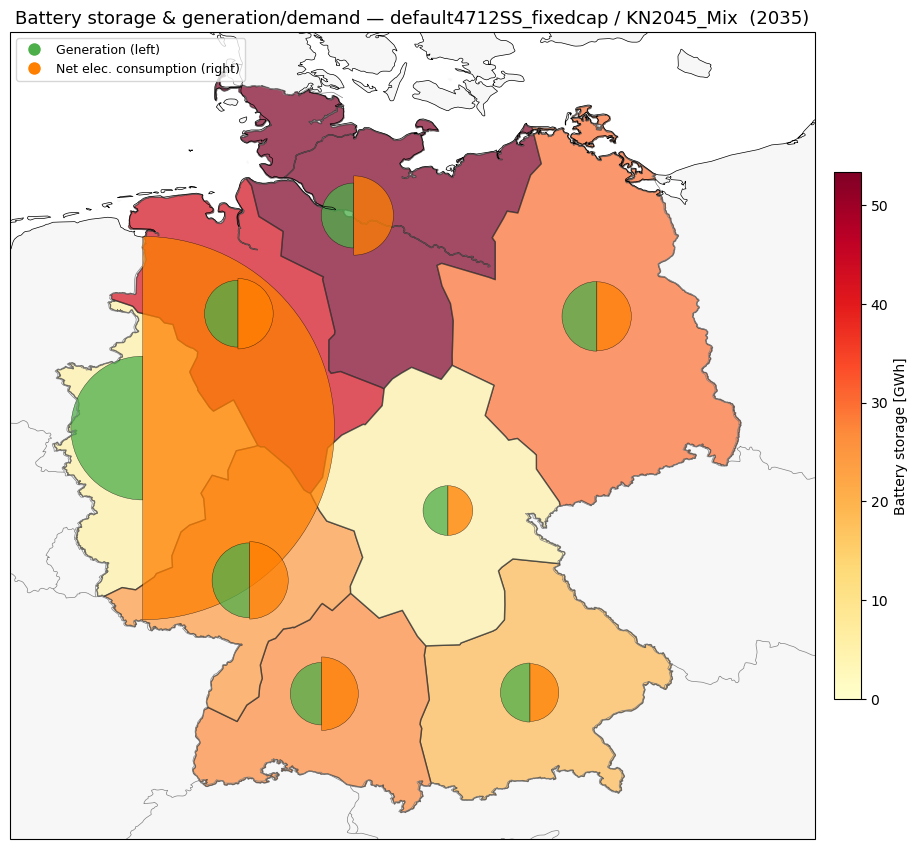

In [54]:
analyzed_nw =nw_fixedcap_2035 # nw_fixedcap_2035 #nw_default8760 #nw_fixedcap_2035 #nw_default_2035          # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# ── Helper: pre-existing capacity (extendable -> *_nom_min, else *_nom) ──
def existing_capacity(df, attr="p"):
    nom, nom_min, ext = f"{attr}_nom", f"{attr}_nom_min", f"{attr}_nom_extendable"
    extendable = df[ext] if ext in df.columns else pd.Series(False, index=df.index)
    return df.loc[extendable, nom_min].sum() + df.loc[~extendable, nom].sum()

# ── Battery capacities ────────────────────────────────────────
bess_stores = n.stores[(n.stores.carrier == "battery") & n.stores.bus.isin(de_all_buses)]
ev_stores = n.stores[(n.stores.carrier == "EV battery") & n.stores.bus.isin(de_all_buses)]
home_batt_stores = n.stores[(n.stores.carrier == "home battery") & n.stores.bus.isin(de_all_buses)]
batt_ch = n.links[(n.links.carrier == "battery charger") & n.links.bus0.isin(de_buses)]
batt_dis = n.links[(n.links.carrier == "battery discharger") & n.links.bus1.isin(de_buses)]
home_batt_ch = n.links[(n.links.carrier == "home battery charger") & n.links.bus0.isin(de_lv_buses)]
home_batt_dis = n.links[(n.links.carrier == "home battery discharger") & n.links.bus1.isin(de_lv_buses)]
batt_charge_cap, batt_discharge_cap = batt_ch.p_nom_opt.sum() / 1e3, batt_dis.p_nom_opt.sum() / 1e3

# Grid + home battery energy mapped to the AC parent bus (for the heatmap)
batt_stores_all = n.stores[n.stores.carrier.isin(["battery", "home battery"]) & n.stores.bus.isin(de_all_buses)]
batt_cap_per_bus = batt_stores_all.e_nom_opt.groupby(batt_stores_all.bus.map(bus_to_ac)).sum() / 1e3  # GWh

# ── Generation per DE AC bus ──────────────────────────────────
gen_p = n.generators_t.p[de_gens].multiply(sw, axis=0).sum()
vre_gen_per_bus = gen_p.groupby(n.generators.loc[de_gens, "bus"]).sum() / 1e6          # TWh (VRE, hydro RoR)
link_gen_e = -n.links_t.p1[link_gen_links.index].multiply(sw, axis=0).sum()            # -p1 = delivery to AC bus
link_gen_per_bus = link_gen_e.groupby(n.links.loc[link_gen_links.index, "bus1"]).sum() / 1e6  # TWh
gen_per_bus = vre_gen_per_bus.add(link_gen_per_bus, fill_value=0)

# ── Net electricity consumption per AC bus (incl. sector coupling) ──
# All withdrawals from DE AC buses via links, minus round-trip storage charging
# (BESS / home-battery energy returns to the grid through the discharger).
round_trip = {"battery charger", "home battery charger"}
consuming = n.links[
    n.links.bus0.isin(de_buses) & (n.links.carrier != "DC")
    & ~n.links.carrier.isin(round_trip) & ~n.links.index.str.endswith("-reversed")
]
total_elec_per_bus = (
    n.links_t.p0[consuming.index].clip(lower=0).multiply(sw, axis=0).sum()
    .groupby(n.links.loc[consuming.index, "bus0"]).sum() / 1e6
)  # TWh (incl. heat pumps, electrolysis, EV charging via the LV grid, ...)
ac_direct_loads = n.loads[n.loads.bus.isin(de_buses)]
if len(ac_direct_loads):
    ac_load_per_bus = (n.loads_t.p_set[ac_direct_loads.index].multiply(sw, axis=0).sum()
                       .groupby(n.loads.loc[ac_direct_loads.index, "bus"]).sum() / 1e6)
    total_elec_per_bus = total_elec_per_bus.add(ac_load_per_bus, fill_value=0)

# ── Summary table ─────────────────────────────────────────────
# "Existing" = pre-existing capacity before this horizon (see existing_capacity()).
W = 63
_p = lambda s: print(f"║{s:<{W}}║")
_hdr = lambda: _p(f"  {'':24s}{'Existing':>10s}  {'Expansion':>10s}  {'Total':>10s} ")
def _row(label, exist, total):
    _p(f"    {label:22s}{exist:10.3f}  {total - exist:10.3f}  {total:10.3f} ")

print("╔" + "═" * W + "╗")
print(f"║{f'Battery Storage Summary — {LABEL} {YEAR}':^{W}}║")
print("╠" + "═" * W + "╣")
_p(" 1) Grid-scale BESS (AC bus)"); _hdr()
_row("Energy [GWh]",   existing_capacity(bess_stores, "e") / 1e3, bess_stores.e_nom_opt.sum() / 1e3)
_row("Charge [GW]",    existing_capacity(batt_ch, "p") / 1e3,     batt_charge_cap)
_row("Discharge [GW]", existing_capacity(batt_dis, "p") / 1e3,    batt_discharge_cap)
_p(""); _p(" 2) Home batteries (LV bus)"); _hdr()
_row("Energy [GWh]",   existing_capacity(home_batt_stores, "e") / 1e3, home_batt_stores.e_nom_opt.sum() / 1e3)
_row("Charge [GW]",    existing_capacity(home_batt_ch, "p") / 1e3,     home_batt_ch.p_nom_opt.sum() / 1e3)
_row("Discharge [GW]", existing_capacity(home_batt_dis, "p") / 1e3,    home_batt_dis.p_nom_opt.sum() / 1e3)
_p(""); _p(" 3) EV batteries (LV bus, exogenous)"); _hdr()
_row("Energy [GWh]",   ev_stores.e_nom.sum() / 1e3, ev_stores.e_nom_opt.sum() / 1e3)
print("╠" + "═" * W + "╣")
_p(f"  VRE + hydro gen.:     {vre_gen_per_bus.sum():>30.1f} TWh")
_p(f"  Dispatchable gen.:    {link_gen_per_bus.sum():>30.1f} TWh   (CHPs, CCGTs, H2, ...)")
_p(f"  Total DE generation:  {gen_per_bus.sum():>30.1f} TWh   (only AC buses (excl. solar rooftop gen))")
_p(f"  Direct elec demand:   {load_per_bus.sum():>30.1f} TWh")
_p(f"  Net elec consump.:    {total_elec_per_bus.sum():>30.1f} TWh   (excl. round-trip storage)")
print("╚" + "═" * W + "╝")

# ── Map: BESS heatmap + two-sided generation / consumption pies ──
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

batt_vals = batt_cap_per_bus.reindex(de_buses, fill_value=0)  # excl. EV batteries
norm = mcolors.Normalize(vmin=0, vmax=max(batt_vals.max(), 0.01))
cmap = plt.cm.YlOrRd
for _, row in de_regions.iterrows():
    ax.add_geometries([row.geometry], crs=ccrs.PlateCarree(),
                      facecolor=cmap(norm(batt_vals.get(row["name"], 0))),
                      edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02).set_label("Battery storage [GWh]")

PIE_SCALE = 0.75
demand_per_bus = total_elec_per_bus          # net (excl. round-trip storage)
max_val = max(gen_per_bus.max(), demand_per_bus.max(), 0.01)
for bus in de_buses:
    bx, by = proj.transform_point(ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree())
    g, d = gen_per_bus.get(bus, 0), demand_per_bus.get(bus, 0)
    r = PIE_SCALE * np.sqrt(max(g, d) / max_val) * 1e5
    if r < 1e3:
        continue
    ax.add_patch(Wedge((bx, by), r, 90, 270, facecolor="#4daf4a", edgecolor="k", linewidth=0.3, alpha=0.75))
    ax.add_patch(Wedge((bx, by), r * np.sqrt(d / max(g, 1e-9)), 270, 90,
                       facecolor="#ff7f00", edgecolor="k", linewidth=0.3, alpha=0.75))

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4daf4a", markersize=10, label="Generation (left)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f00", markersize=10, label="Net elec. consumption (right)"),
], loc="upper left", fontsize=9)
ax.set_title(f"Battery storage & generation/demand — {TITLE}", fontsize=13)
plt.tight_layout()
plt.show()


## 2 — Installed Capacity & Production Pie Charts (Germany)
Three pies for the chosen network:
1. installed **generation** capacity [GW],
2. **electricity produced** over the whole year per technology [TWh],
3. installed **storage** capacity (discharge power) [GW].

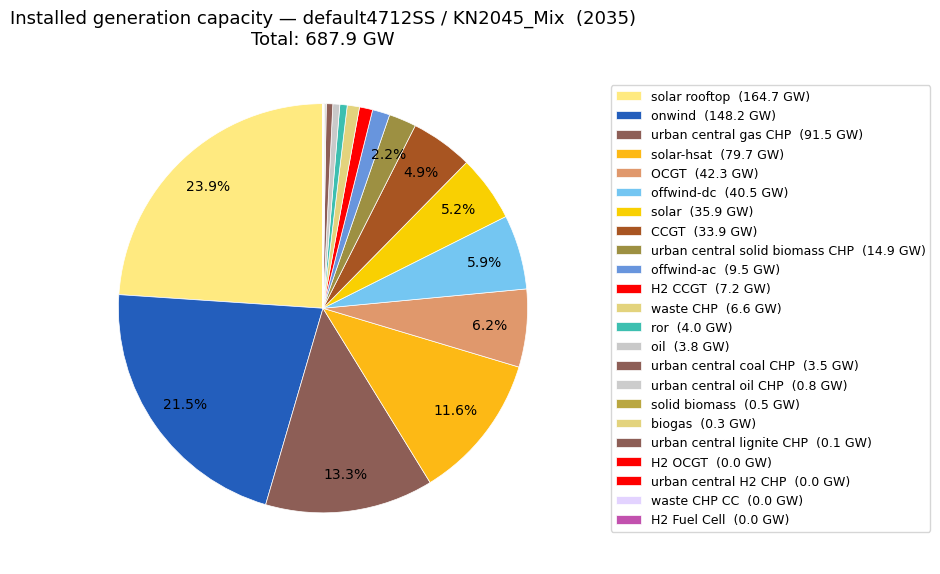

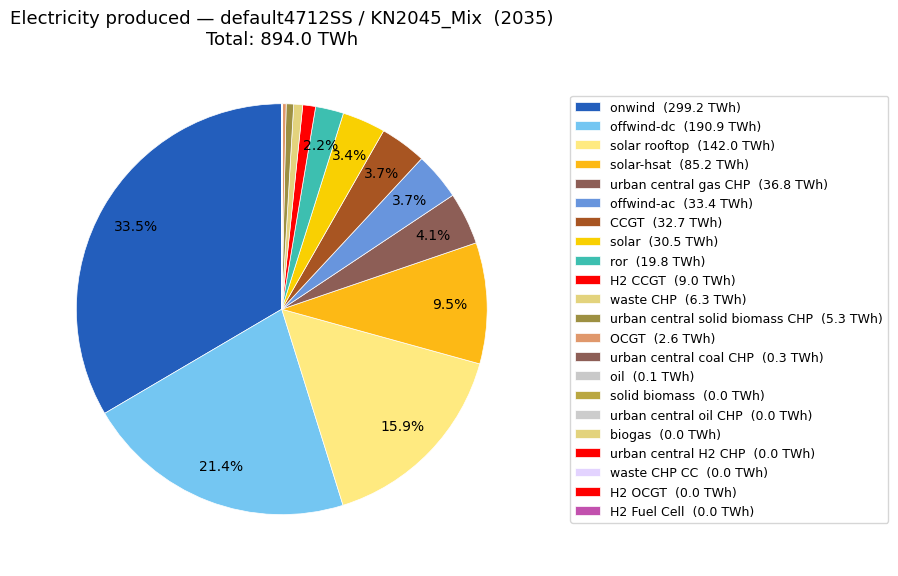

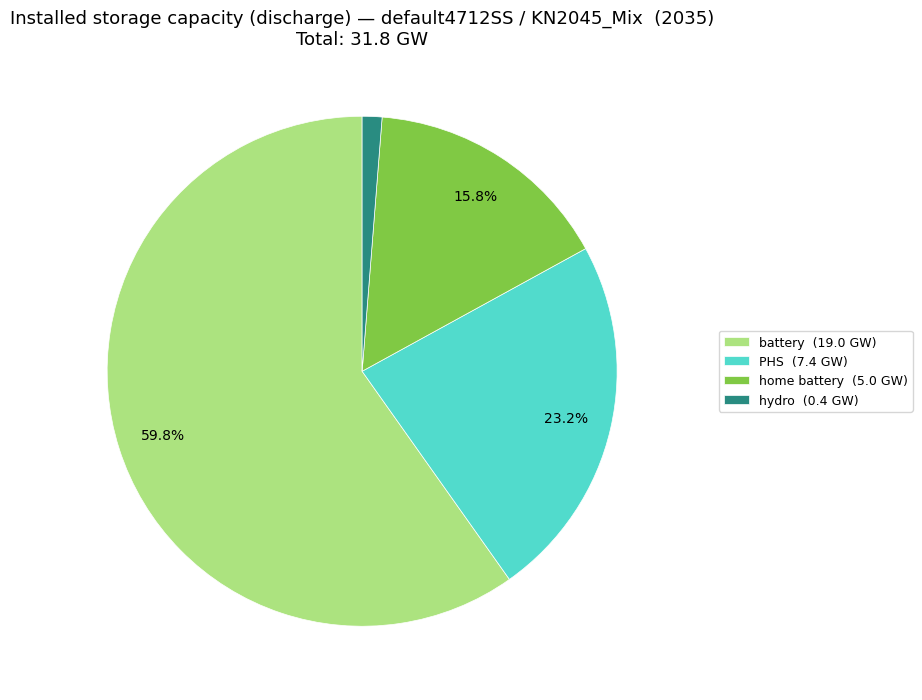

In [51]:
analyzed_nw = nw_default_2035         # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# Electricity generators = generators on DE AC / low-voltage buses (onwind,
# solar, solar rooftop, ror, ...). Excludes fuel-potential "generators" that
# sit on biomass / gas carrier buses.
elec_gen_buses = n.buses[(n.buses.country == "DE") & n.buses.carrier.isin(["AC", "low voltage"])].index
gens = n.generators[n.generators.bus.isin(elec_gen_buses)]
# Storage: PHS / hydro (storage units) + battery & home-battery discharge links
su = n.storage_units[n.storage_units.bus.isin(de_buses)]
batt_dis = n.links[(n.links.carrier == "battery discharger") & n.links.bus1.isin(de_buses)]
home_dis = n.links[(n.links.carrier == "home battery discharger") & n.links.bus1.isin(de_lv_buses)]


def pie(series, title, unit):
    """Draw one labelled pie from a carrier -> value Series (values in 'unit')."""
    s = series[series > 1e-3].sort_values(ascending=False)
    colors = [tech_colors.get(c, "#cccccc") for c in s.index]
    fig, ax = plt.subplots(figsize=(9, 9))
    wedges, _, _ = ax.pie(
        s.values, autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
        colors=colors, startangle=90, pctdistance=0.82,
        wedgeprops=dict(edgecolor="w", linewidth=0.5),
    )
    ax.legend(wedges, [f"{c}  ({v:.1f} {unit})" for c, v in s.items()],
              loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9)
    ax.set_title(f"{title} — {TITLE}\nTotal: {s.sum():.1f} {unit}", fontsize=13)
    plt.tight_layout()
    plt.show()


# ── 1) Installed generation capacity [GW] ─────────────────────
# VRE generators + dispatchable links delivering into the AC grid
# (gas / H2 / CHP / biomass / ...). NB: link p_nom_opt is input-referenced.
gen_capacity = (
    gens.groupby("carrier").p_nom_opt.sum()
    .add(link_gen_links.groupby("carrier").p_nom_opt.sum(), fill_value=0)
) / 1e3
pie(gen_capacity, "Installed generation capacity", "GW")

# ── 2) Electricity produced over the whole year [TWh] ─────────
gen_energy = (
    n.generators_t.p[gens.index].multiply(sw, axis=0).sum().groupby(gens.carrier).sum()
    .add((-n.links_t.p1[link_gen_links.index].multiply(sw, axis=0).sum())
         .groupby(link_gen_links.carrier).sum(), fill_value=0)
) / 1e6
pie(gen_energy, "Electricity produced", "TWh")

# ── 3) Installed storage capacity (discharge power) [GW] ──────
storage_capacity = su.groupby("carrier").p_nom_opt.sum() / 1e3
storage_capacity["battery"] = batt_dis.p_nom_opt.sum() / 1e3
storage_capacity["home battery"] = home_dis.p_nom_opt.sum() / 1e3
pie(storage_capacity, "Installed storage capacity (discharge)", "GW")


## 3 — Electricity Price Comparison (German nodes)
Overlay the German nodal marginal prices of one or more networks over a chosen
time window. Each network is drawn in a single colour, one thin line per DE node.

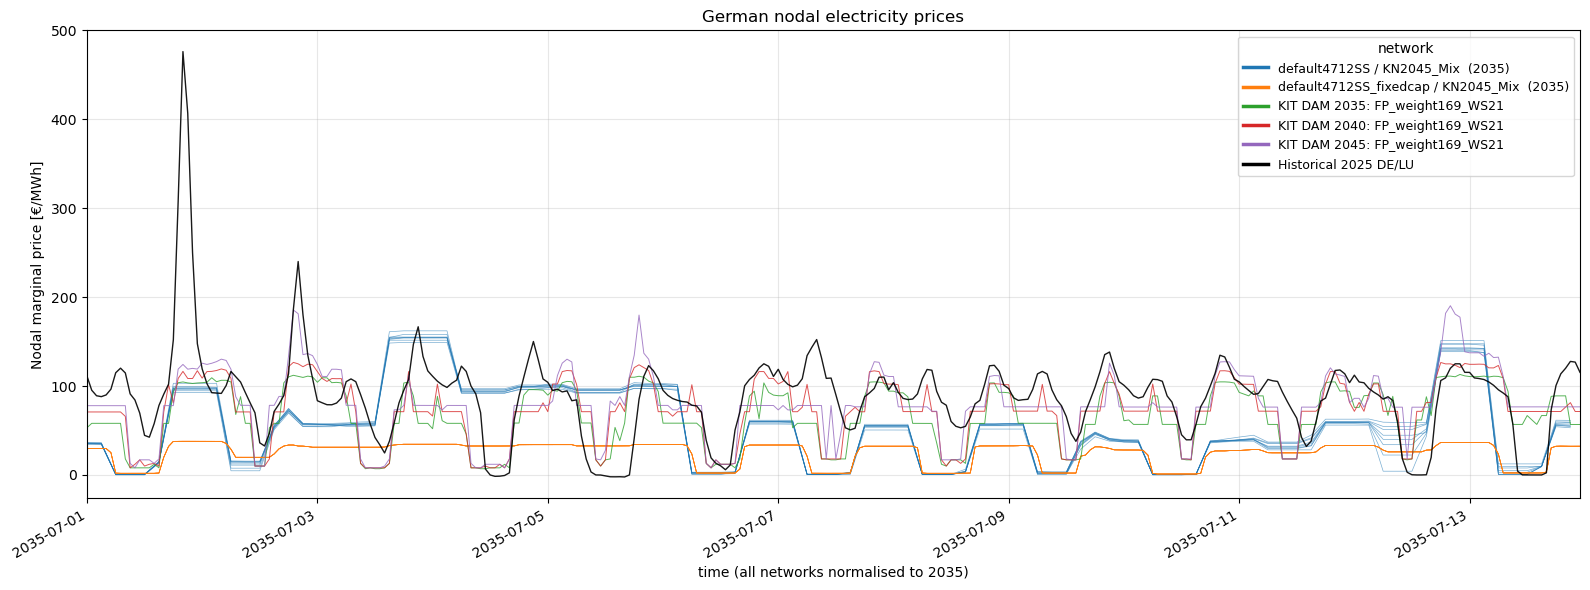

In [69]:
# ── German nodal electricity prices — compare several networks ──
# bundles to overlay. Each network -> one colour, one thin line per German node.
selected = [nw_default_2035, nw_fixedcap_2035]   # <- networks to compare #, nw_fixedcap_2035, nw_test_fixedcap_2035, nw_test02_custom_map_2035, nw_ariadne, nw_default8760, nw_ariadne_2035, nw_ariadne_2040, nw_ariadne_2045,

# ── External DAM price series from KIT agent-based model ──────
# One CSV per horizon, each with 360 hourly DE-LU price series (8760 hours).
# Add column names per dataset to overlay them on the plot.
dam_datasets = {
    2035: (ROOT / "thesis" / "DE_LU_2035_360prices.csv", ["FP_weight169_WS21"]),
    2040: (ROOT / "thesis" / "DE_LU_2040_360prices.csv", ["FP_weight169_WS21"]),
    2045: (ROOT / "thesis" / "DE_LU_2045_360prices.csv", ["FP_weight169_WS21"]),
}

# ── Historical DE/LU day-ahead prices 2025 (SMARD export) ─────
# Semicolon-separated, German decimals, one column per bidding zone.
# Plotted regardless of REF_YEAR (normalised onto REF_YEAR like the networks).
plot_hist_2025 = True                                                            # <- toggle historical overlay
hist_csv   = ROOT / "thesis" / "Gro_handelspreise_202501010000_202601010000_Stunde.csv"
hist_col   = "Deutschland/Luxemburg [€/MWh] Berechnete Auflösungen"             # <- German column
hist_color = "black"

# Time window, given in the REF_YEAR calendar below (set both to None for full year).
# Networks from different planning horizons are normalised onto REF_YEAR so their
# curves line up on the same axis (month/day/hour are preserved).
REF_YEAR = 2035
T_START = "2035-07-01"
T_END   = "2035-07-14"

fig, ax = plt.subplots(figsize=(16, 6))
palette = plt.cm.tab10.colors

for k, nw in enumerate(selected):
    n, de = nw["n"], nw["de_buses"]
    idx = n.snapshots + pd.DateOffset(years=REF_YEAR - n.snapshots[0].year)
    prices = n.buses_t.marginal_price[de].copy()
    prices.index = idx
    if T_START and T_END:
        prices = prices[(idx >= T_START) & (idx < T_END)]

    color = palette[k % len(palette)]
    for bus in de:
        ax.plot(prices.index, prices[bus], color=color, linewidth=0.5, alpha=0.6)
    ax.plot([], [], color=color, linewidth=2.5, label=nw["TITLE"])   # one legend entry / network

# ── Plot external DAM series ──────────────────────────────────
j = 0
for dam_year, (dam_csv, dam_series_to_plot) in dam_datasets.items():
    if not dam_series_to_plot:
        continue
    dam_df = pd.read_csv(dam_csv)
    dam_idx = pd.date_range(start=f"{REF_YEAR}-01-01", periods=len(dam_df), freq="h")
    dam_df.index = dam_idx
    for col in dam_series_to_plot:
        series = dam_df[col]
        if T_START and T_END:
            series = series[(dam_idx >= T_START) & (dam_idx < T_END)]
        color = palette[(len(selected) + j) % len(palette)]
        ax.plot(series.index, series.values, color=color, linewidth=0.7, alpha=0.8)
        ax.plot([], [], color=color, linewidth=2.5, label=f"KIT DAM {dam_year}: {col}")
        j += 1

# ── Plot historical 2025 DE/LU series ─────────────────────────
if plot_hist_2025:
    hist_df = pd.read_csv(hist_csv, sep=";", decimal=",", na_values="-",
                          usecols=["Datum von", hist_col],
                          parse_dates=["Datum von"], dayfirst=True)
    hist_df = hist_df.set_index("Datum von")
    hist_idx = hist_df.index + pd.DateOffset(years=REF_YEAR - hist_df.index[0].year)
    series = hist_df[hist_col]
    series.index = hist_idx
    if T_START and T_END:
        series = series[(hist_idx >= T_START) & (hist_idx < T_END)]
    ax.plot(series.index, series.values, color=hist_color, linewidth=1.0, alpha=0.9)
    ax.plot([], [], color=hist_color, linewidth=2.5, label="Historical 2025 DE/LU")

ax.set_ylabel("Nodal marginal price [€/MWh]")
ax.set_xlabel(f"time (all networks normalised to {REF_YEAR})")
ax.set_title("German nodal electricity prices")
ax.margins(x=0)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=9, title="network")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


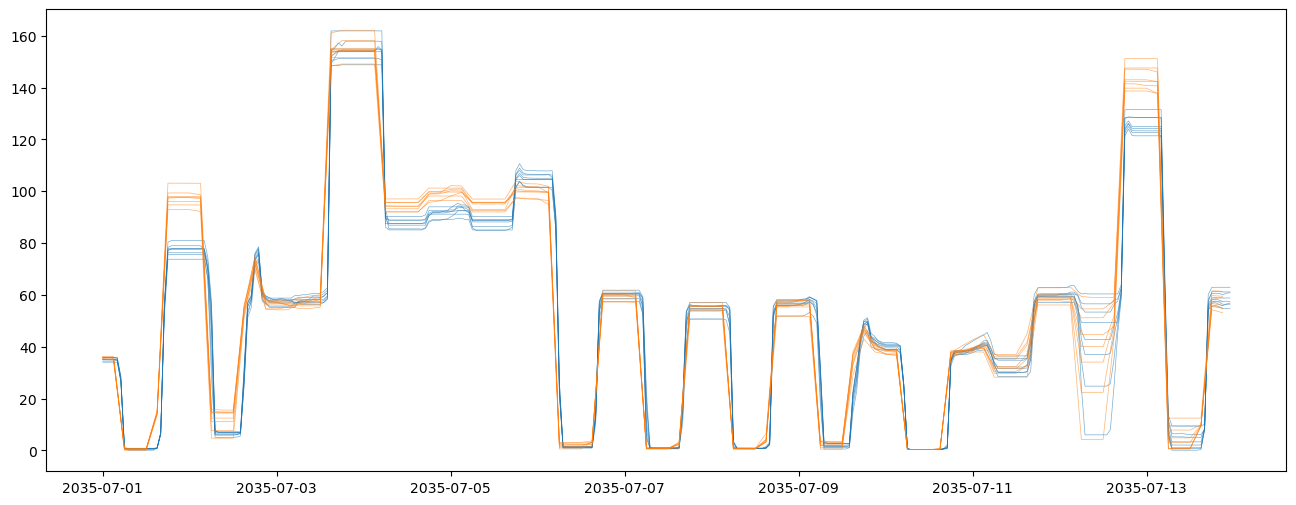

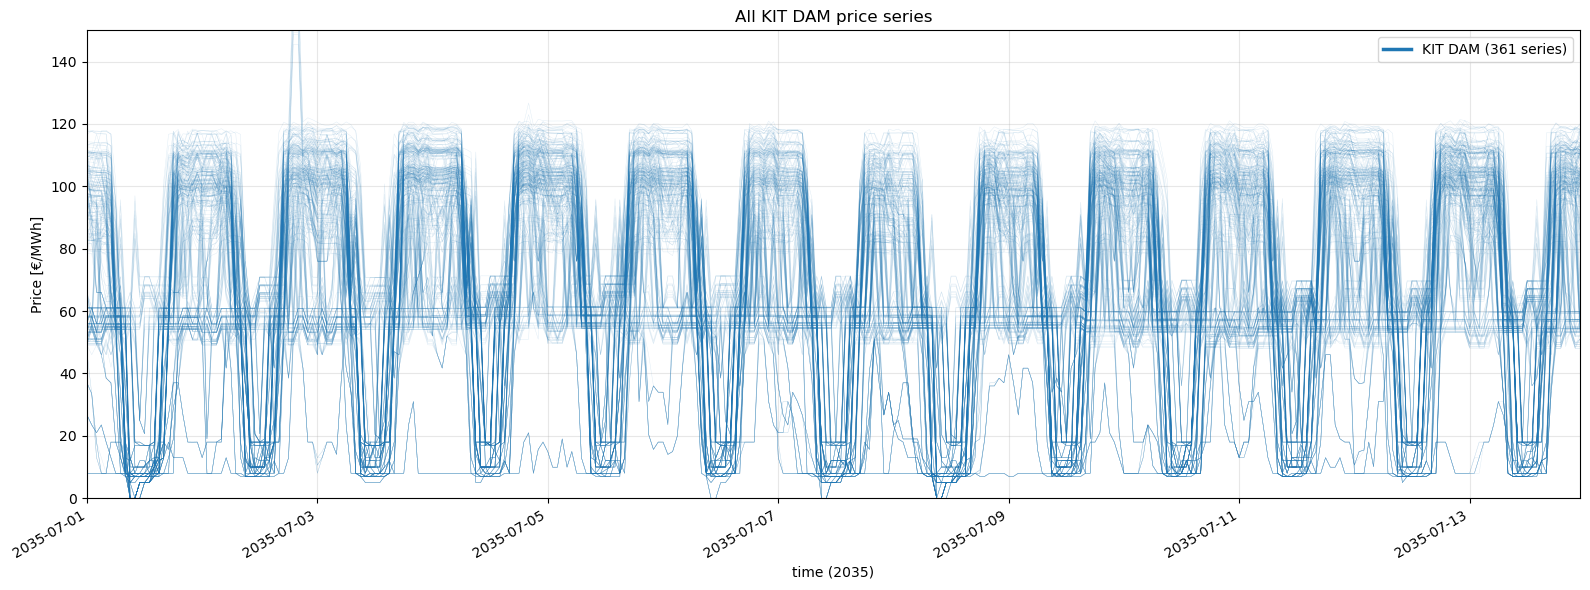

In [43]:
# ── Quick look: plot ALL 360 KIT DAM price series from the CSV ──
REF_YEAR = 2035
T_START =  "2035-07-01"
T_END   =  "2035-07-14"

dam_df = pd.read_csv(dam_csv)
dam_df.index = pd.date_range(start=f"{REF_YEAR}-01-01", periods=len(dam_df), freq="h")

fig, ax = plt.subplots(figsize=(16, 6))
palette = plt.cm.tab10.colors

for k, nw in enumerate(selected):
    n, de = nw["n"], nw["de_buses"]
    idx = n.snapshots + pd.DateOffset(years=REF_YEAR - n.snapshots[0].year)
    prices = n.buses_t.marginal_price[de].copy()
    prices.index = idx
    if T_START and T_END:
        prices = prices[(idx >= T_START) & (idx < T_END)]

    color = palette[k % len(palette)]
    for bus in de:
        ax.plot(prices.index, prices[bus], color=color, linewidth=0.5, alpha=0.6)
    ax.plot([], [], color=color, linewidth=2.5, label=nw["TITLE"])   # one legend entry / network


plot_df = dam_df
if T_START and T_END:
    plot_df = dam_df[(dam_df.index >= T_START) & (dam_df.index < T_END)]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(plot_df.index, plot_df.values, color="tab:blue", linewidth=0.3, alpha=0.15)
ax.plot([], [], color="tab:blue", linewidth=2.5, label=f"KIT DAM ({plot_df.shape[1]} series)")

ax.set_ylabel("Price [€/MWh]")
ax.set_xlabel(f"time ({REF_YEAR})")
ax.set_title("All KIT DAM price series")
ax.margins(x=0)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
ax.set_ylim(-0, 150)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [43]:
n = nw_fixedcap_2035["n"]
#n.snapshots[n.snapshots.month == 2]        # all snapshots in February
n.snapshots

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 01:00:00',
               '2013-01-01 02:00:00', '2013-01-01 03:00:00',
               '2013-01-01 04:00:00', '2013-01-01 05:00:00',
               '2013-01-01 06:00:00', '2013-01-01 07:00:00',
               '2013-01-01 08:00:00', '2013-01-01 09:00:00',
               ...
               '2013-12-31 14:00:00', '2013-12-31 15:00:00',
               '2013-12-31 16:00:00', '2013-12-31 17:00:00',
               '2013-12-31 18:00:00', '2013-12-31 19:00:00',
               '2013-12-31 20:00:00', '2013-12-31 21:00:00',
               '2013-12-31 22:00:00', '2013-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

## 4 — Network Topology Map
All AC buses, lines, and DC links on a map of Germany.

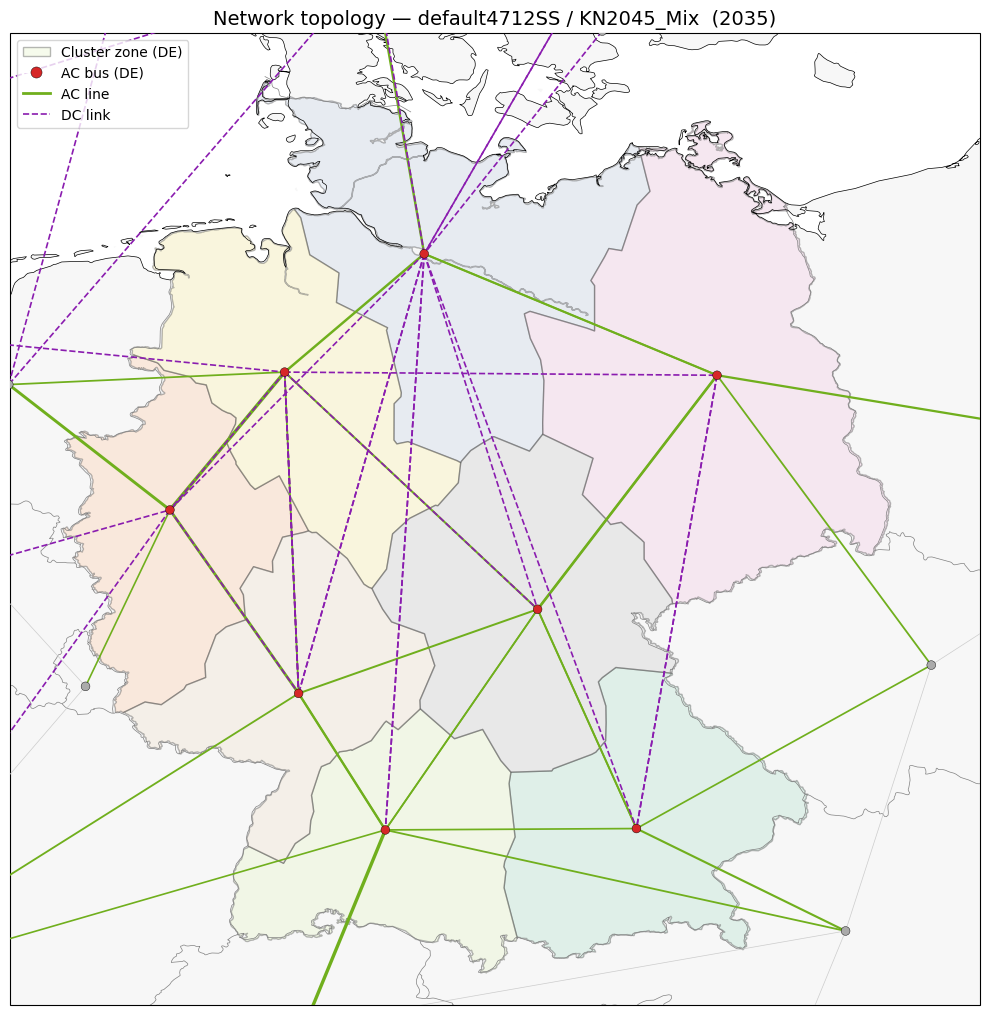

In [4]:
analyzed_nw = nw_default          # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# ── DE cluster regions (Voronoi zones) ────────────────────────
# Light transparent fill + solid outline per cluster
cluster_cmap = plt.cm.Pastel2
for i, (_, row) in enumerate(de_regions.iterrows()):
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cluster_cmap(i / max(len(de_regions) - 1, 1)),
        edgecolor="#333333", linewidth=1.0, alpha=0.35, zorder=1,
    )

# AC buses (ac_buses comes from the loaded bundle)
ax.scatter(
    ac_buses.x, ac_buses.y,
    transform=ccrs.PlateCarree(), s=40, zorder=5,
    c=["#d62728" if b in de_buses else "#aaaaaa" for b in ac_buses.index],
    edgecolors="k", linewidths=0.3,
)

# AC lines
for _, ln in n.lines.iterrows():
    b0, b1 = n.buses.loc[ln.bus0], n.buses.loc[ln.bus1]
    is_de = ln.bus0 in de_buses or ln.bus1 in de_buses
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(),
        color="#70af1d" if is_de else "#cccccc",
        linewidth=1.0 + 1.5 * (ln.s_nom_opt / n.lines.s_nom_opt.max()) if is_de else 0.5,
        zorder=3,
    )

# DC links (exclude "-reversed" duplicates so each corridor is drawn once)
dc_links = n.links[
    (n.links.carrier == "DC") & ~n.links.index.str.endswith("-reversed")
]
for _, lk in dc_links.iterrows():
    b0, b1 = n.buses.loc[lk.bus0], n.buses.loc[lk.bus1]
    ax.plot(
        [b0.x, b1.x], [b0.y, b1.y],
        transform=ccrs.PlateCarree(), color="#8a1caf",
        linewidth=1.2, linestyle="--", zorder=4,
    )

# Legend with proxy artists
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cluster_cmap(0.5), edgecolor="#333333", linewidth=1.0, alpha=0.35, label="Cluster zone (DE)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d62728",
           markeredgecolor="k", markeredgewidth=0.3, markersize=8, label="AC bus (DE)"),
    Line2D([0], [0], color="#70af1d", linewidth=2.0, label="AC line"),
    Line2D([0], [0], color="#8a1caf", linewidth=1.2, linestyle="--", label="DC link"),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title(f"Network topology — {TITLE}", fontsize=14)
plt.tight_layout()
plt.show()


## 5 — Mean Electricity Price Map
Mean marginal price (€/MWh) at each German AC bus, written on the map.

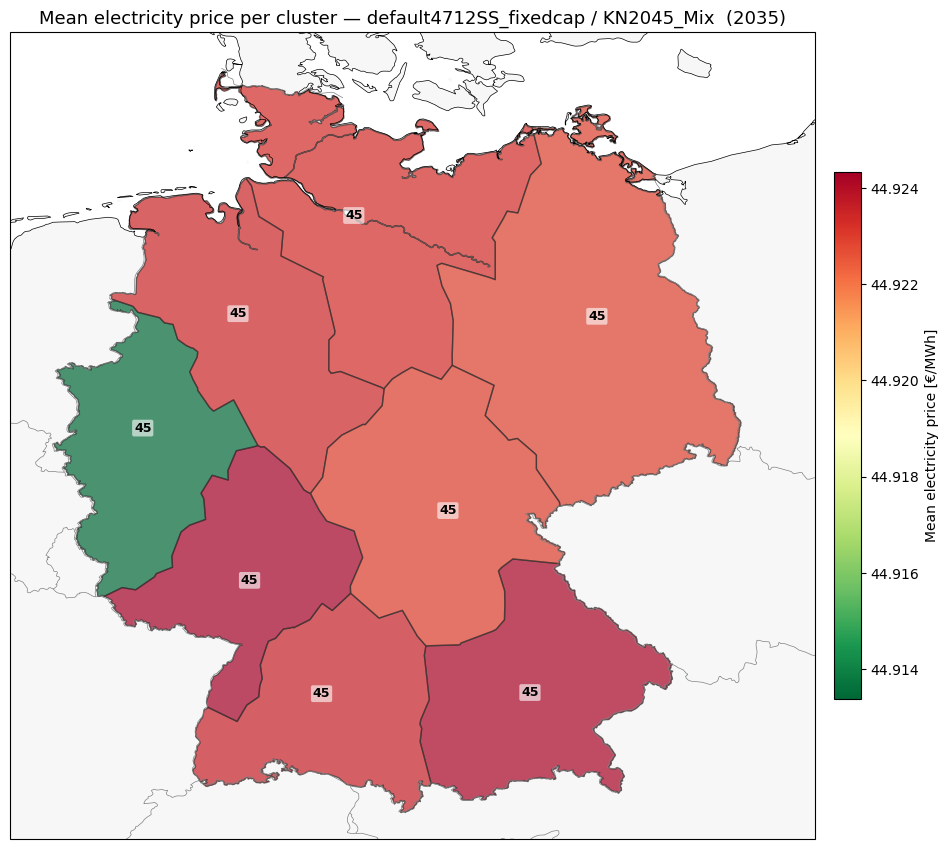


DE load-weighted avg price: 44.9 €/MWh


In [49]:
analyzed_nw = nw_fixedcap_2035 #nw_default_2030        # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# Weighted-average marginal price per bus (weighted by snapshot hours)
mean_price = (n.buses_t.marginal_price[de_buses].multiply(sw, axis=0)).sum() / sw.sum()

fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={"projection": proj})
ax.set_extent(DE_BOUNDS, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5, color="grey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")

# ── Fill DE cluster zones with price heatmap ──────────────────
norm_p = mcolors.Normalize(vmin=mean_price.min(), vmax=mean_price.max())
cmap_p = plt.cm.RdYlGn_r

for _, row in de_regions.iterrows():
    bus = row["name"]
    val = mean_price.get(bus, mean_price.mean())
    ax.add_geometries(
        [row.geometry], crs=ccrs.PlateCarree(),
        facecolor=cmap_p(norm_p(val)),
        edgecolor="#333333", linewidth=1.0, alpha=0.7, zorder=1,
    )

# Colorbar via ScalarMappable
sm = plt.cm.ScalarMappable(cmap=cmap_p, norm=norm_p)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label("Mean electricity price [€/MWh]")

# ── Annotate each cluster with its price ──────────────────────
for bus in de_buses:
    bx, by = proj.transform_point(
        ac_buses.loc[bus, "x"], ac_buses.loc[bus, "y"], ccrs.PlateCarree()
    )
    ax.annotate(
        f"{mean_price[bus]:.0f}",
        xy=(bx, by), fontsize=9, fontweight="bold",
        ha="center", va="center",
        color="k",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6),
        zorder=5,
    )

ax.set_title(f"Mean electricity price per cluster — {TITLE}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nDE load-weighted avg price: "
      f"{(mean_price * load_per_bus.reindex(de_buses, fill_value=0)).sum() / load_per_bus.sum():.1f} €/MWh")

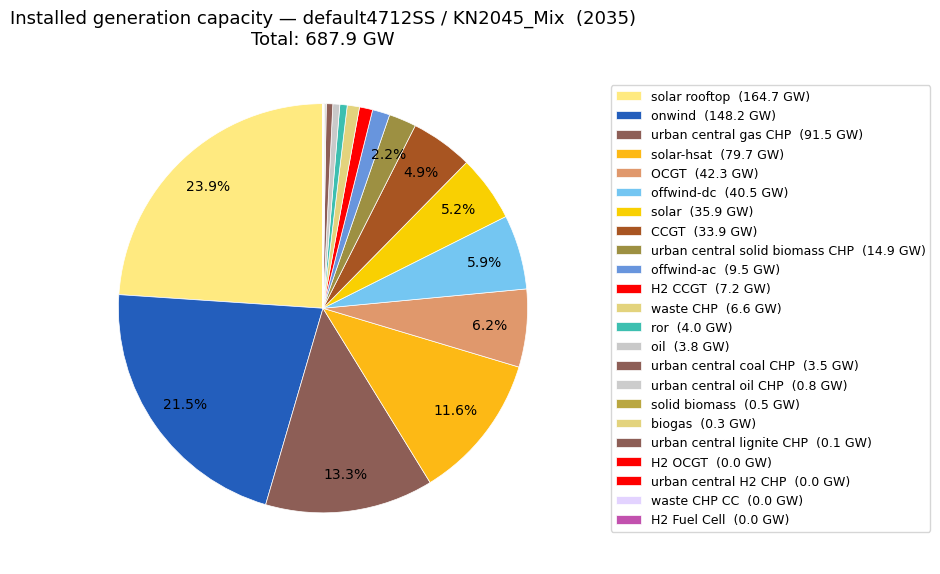

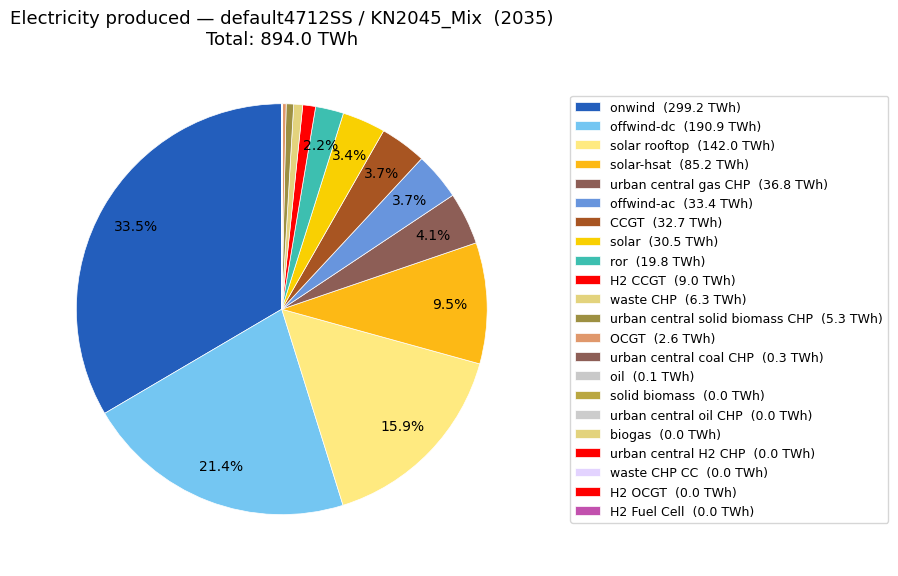

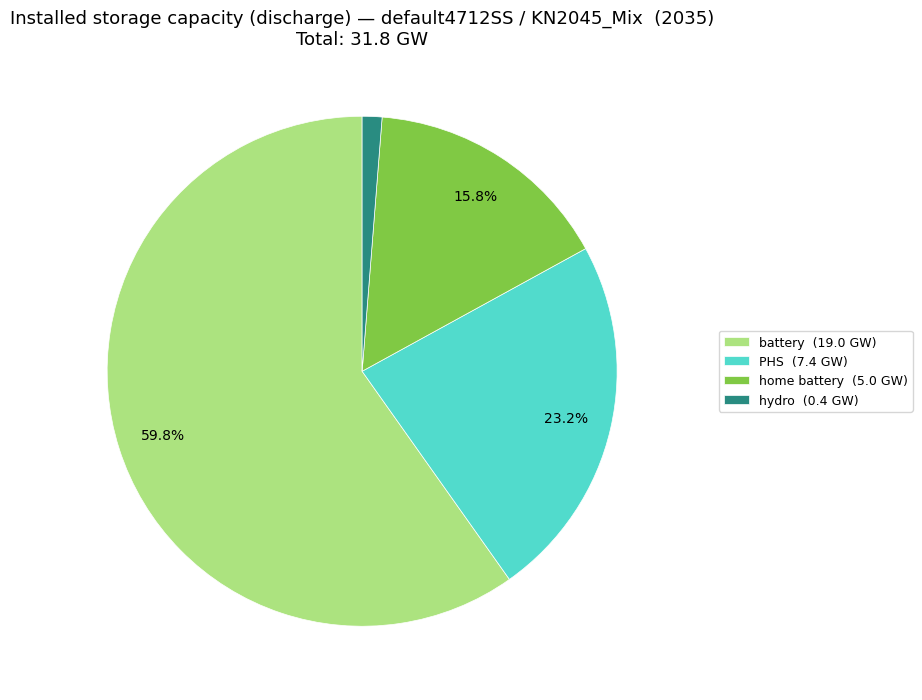

## 6 — Generation, Demand & Storage Dispatch
Stacked area plot of electricity generation, demand, and battery charge/discharge.  
Set `T_START` / `T_END` to zoom into a specific period (e.g. a winter week).

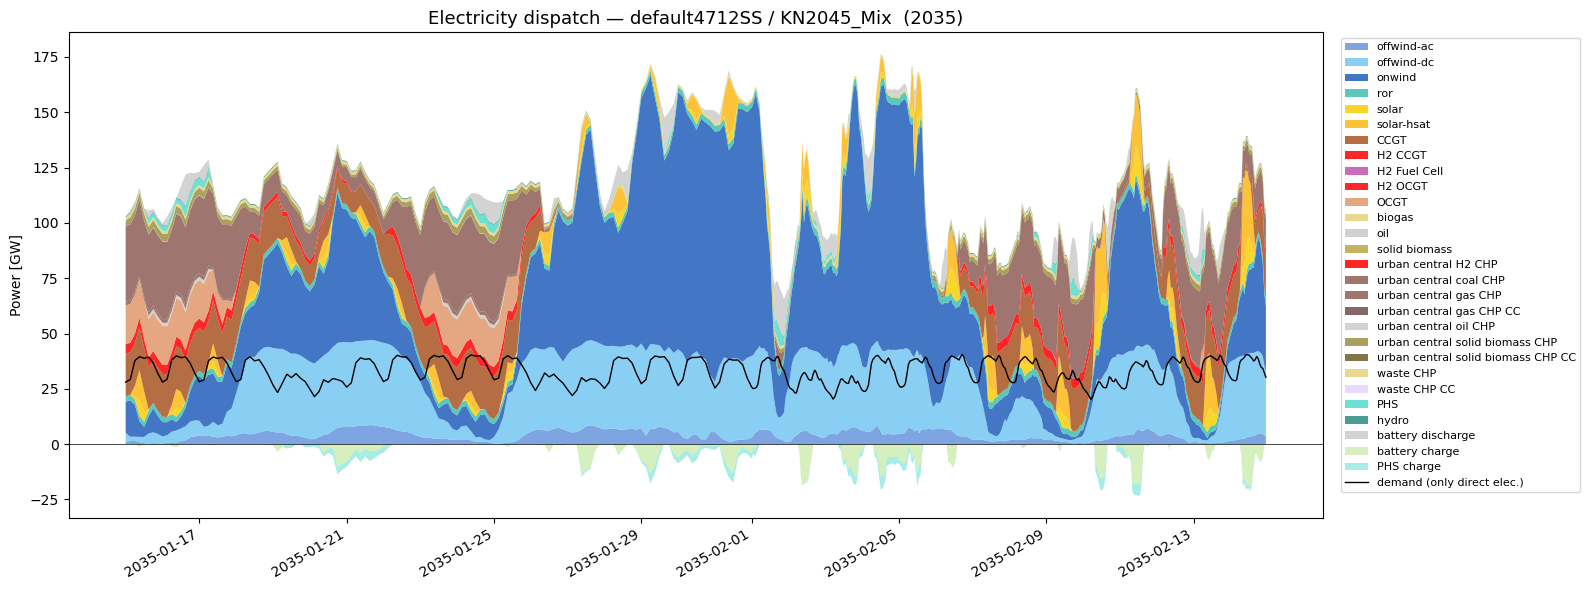

In [14]:
analyzed_nw = nw_default_2035          # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# ── Time window (set to None for full year) ───────────────────
T_START = "2035-01-15"#None   # e.g. "2013-01-15"
T_END   = "2035-02-15"#None   # e.g. "2013-01-29"

ts = n.snapshots
# Shift weather-year timestamps to the model planning horizon for display
year_offset = pd.DateOffset(years=YEAR - ts[0].year)
ts_display = ts + year_offset

if T_START and T_END:
    # Accept dates in either the model year or the weather year
    mask = (ts_display >= T_START) & (ts_display < T_END)
    ts_sel = ts[mask]
    ts_sel_display = ts_display[mask]
else:
    ts_sel = ts
    ts_sel_display = ts_display

# ── Generation by carrier ─────────────────────────────────────
gen_ts = n.generators_t.p[de_gens].loc[ts_sel]
gen_by_carrier = gen_ts.T.groupby(n.generators.loc[de_gens, "carrier"]).sum().T / 1e3  # GW

# Storage-unit dispatch (PHS, hydro)
su_ts = n.storage_units_t.p[de_sus].loc[ts_sel]
su_by_carrier = su_ts.T.groupby(n.storage_units.loc[de_sus, "carrier"]).sum().T / 1e3

# Battery charge / discharge via links
batt_ch_links = n.links[(n.links.carrier == "battery charger") & (n.links.bus0.isin(de_buses))]
batt_dis_links = n.links[(n.links.carrier == "battery discharger") & (n.links.bus1.isin(de_buses))]
batt_charge = n.links_t.p0[batt_ch_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_ch_links) else pd.Series(0, index=ts_sel)
batt_discharge = -n.links_t.p1[batt_dis_links.index].loc[ts_sel].sum(axis=1) / 1e3 if len(batt_dis_links) else pd.Series(0, index=ts_sel)

# Link-based dispatchable generation (CHPs, CCGTs, H2 turbines, etc.)
# link_gen_links comes from the loaded network bundle
disp_gen_ts = -n.links_t.p1[link_gen_links.index].loc[ts_sel]  # −p1 = delivery to AC bus
disp_by_carrier = disp_gen_ts.T.groupby(
    n.links.loc[link_gen_links.index, "carrier"]
).sum().T / 1e3  # GW
# Drop carriers with negligible output
disp_by_carrier = disp_by_carrier.loc[:, disp_by_carrier.sum() > 0.01]

# Total electricity demand
elec_load_ts = n.loads_t.p_set[elec_loads.index].loc[ts_sel].sum(axis=1) / 1e3  # GW

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Stack generation + discharge (positive)
pos_data = gen_by_carrier.copy()
for c in disp_by_carrier.columns:
    pos_data[c] = disp_by_carrier[c]
for c in su_by_carrier.columns:
    pos_data[c] = su_by_carrier[c].clip(lower=0)
pos_data["battery discharge"] = batt_discharge
pos_colors = [tech_colors.get(c, "#cccccc") for c in pos_data.columns]
ax.stackplot(ts_sel_display, pos_data.values.T, labels=pos_data.columns, colors=pos_colors, alpha=0.85)

# Negative: battery charging + pumped-hydro charging
neg = pd.DataFrame(index=ts_sel)
neg["battery charge"] = -batt_charge
for c in su_by_carrier.columns:
    neg_vals = su_by_carrier[c].clip(upper=0)
    if (neg_vals < 0).any():
        neg[c + " charge"] = neg_vals
neg_colors = [tech_colors.get(c.replace(" charge", ""), "#999999") for c in neg.columns]
ax.stackplot(ts_sel_display, neg.values.T, colors=neg_colors, alpha=0.5, labels=neg.columns)

# Demand line
ax.plot(ts_sel_display, elec_load_ts.values, color="k", linewidth=1.0, label="demand (only direct elec.)")

ax.set_ylabel("Power [GW]")
ax.set_title(f"Electricity dispatch — {TITLE}", fontsize=13)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, ncol=1)
ax.axhline(0, color="k", linewidth=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7 — Electricity Price Time Series DataFrame
Per-cluster marginal prices and their mean across all DE clusters.

        DE0_0   DE0_1  DE0_10  DE0_11  DE0_12  DE0_13  DE0_14  DE0_15  DE0_16  \
count  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0   
mean     99.3   101.6   102.3    96.0   101.2   103.2   103.2    90.2    96.0   
std     129.3   127.0   126.0   124.0   130.2   129.5   122.8   121.1   122.1   
min       0.0    -5.4     0.0     0.0    -0.3     0.0    -0.3     0.0    -5.1   
25%      42.6    44.9    43.2    36.1    38.7    45.3    46.7    32.9    29.6   
50%      67.6    67.8    67.1    66.1    68.2    68.3    68.0    64.7    66.7   
75%     101.3   125.1   134.4   106.0   112.7   126.1   141.3    89.2   108.5   
max    1576.1  1538.3  1516.4  1510.1  1553.4  1580.3  1476.6  1510.0  1519.6   

       DE0_17  DE0_18  DE0_19   DE0_2  DE0_20  DE0_21  DE0_22  DE0_23  DE0_24  \
count  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0  2920.0   
mean     95.7   101.7    97.1    91.7   102.8   101.8    87.7    87.5    99.3   
std     128.9   126.3   128

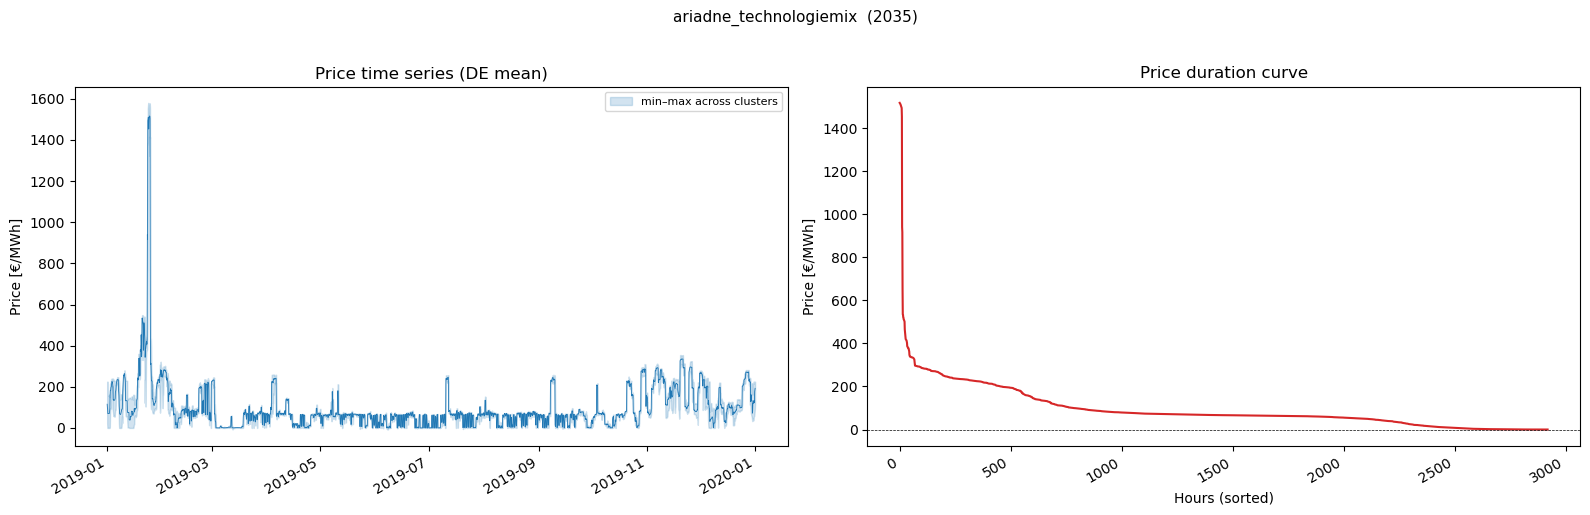

,DE0_0,DE0_1,DE0_10,DE0_11,DE0_12,DE0_13,DE0_14,DE0_15,DE0_16,DE0_17,DE0_18,DE0_19,DE0_2,DE0_20,DE0_21,DE0_22,DE0_23,DE0_24,DE0_25,DE0_26,DE0_27,DE0_28,DE0_29,DE0_3,DE0_4,DE0_5,DE0_6,DE0_7,DE0_8,DE0_9,DE_mean
snapshot,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,100.127616,138.330346,165.768393,74.163221,208.929272,170.730929,156.627812,48.961189,90.602731,20.865930,134.155715,63.078134,63.589690,225.013077,177.116228,41.471285,46.240966,110.361062,177.197087,68.737065,169.049884,39.976771,111.197444,144.359281,79.363270,42.366326,193.071450,156.677476,59.176727,185.075370,115.412725
2019-01-01 03:00:00,88.071642,133.353371,164.494979,38.002798,208.929238,170.972653,155.740362,17.184345,21.221464,0.036005,134.149855,49.695497,27.762385,225.013192,175.540408,22.378888,17.134728,90.922116,174.304010,23.007896,167.044070,18.163813,104.584231,138.964357,25.613399,18.969522,190.330387,155.167185,0.057217,185.075326,98.062845
2019-01-01 06:00:00,88.078514,133.935188,164.208605,29.728402,208.929545,176.274932,155.739900,11.256156,0.054961,0.034996,139.781592,31.992246,19.867933,224.858952,175.540374,12.890878,11.076811,84.556949,177.066746,13.640399,166.817323,11.654878,95.840456,138.525924,11.404727,11.760314,189.777418,155.067483,0.055135,185.075422,94.183105
2019-01-01 09:00:00,62.271222,104.459167,140.170606,14.380241,155.341644,144.015827,142.305610,5.921787,0.054777,0.035010,122.767060,0.175856,9.516703,157.736393,142.519361,11.705711,5.906678,36.954784,131.189754,5.611145,138.669288,2.852863,0.064518,104.561707,3.528114,6.545971,155.940826,137.089183,0.054893,148.539527,69.696208
2019-01-01 12:00:00,62.271377,104.319911,140.171189,14.998029,155.341618,144.015876,142.306004,5.980138,0.054729,0.034993,122.145716,0.122119,9.736161,157.736399,142.519377,11.709154,5.953987,37.160462,131.188751,5.394023,138.669557,2.849167,0.064470,104.640902,2.859907,6.560983,155.947724,137.062828,0.054854,148.539557,69.680332
2019-01-01 15:00:00,62.428328,104.320042,140.180688,13.270569,155.341561,144.016054,142.306002,5.853394,0.054925,0.034994,122.043232,0.052952,9.198614,157.736424,142.527631,11.709127,5.856417,37.160961,131.139746,6.222546,138.839030,2.772133,0.065372,104.641352,5.144771,6.551496,162.467445,137.272176,0.056263,148.540203,69.926815
2019-01-01 18:00:00,62.428395,104.319814,140.180754,13.280114,155.341509,144.015751,142.305569,5.854609,0.054734,0.035000,122.042431,0.049562,9.204140,157.736408,142.527673,11.709194,5.857347,37.190564,131.188704,6.226872,138.774121,2.771502,0.064448,104.642442,5.148579,6.551606,162.416766,137.269671,0.055761,148.539643,69.926123
2019-01-01 21:00:00,62.428427,104.319969,140.180741,13.280417,155.341550,144.015739,142.305631,5.855091,0.054733,0.035024,122.042562,0.049623,9.204624,157.736412,142.527635,11.709663,5.857812,37.190702,131.188740,6.226693,138.774860,2.771747,0.064447,104.642525,5.148600,6.552001,162.416726,137.269658,0.056535,148.539656,69.926285
2019-01-02 00:00:00,62.428475,104.319898,140.180765,13.280442,155.341575,144.015723,142.305584,5.854965,0.054742,0.035004,122.042565,0.049274,9.204355,157.736424,142.527684,11.709273,5.857617,37.190586,131.188766,6.227267,138.774014,2.771567,0.064449,104.642421,5.148793,6.551743,162.416636,137.269704,0.057195,148.539657,69.926239


In [20]:
analyzed_nw = nw_ariadne          # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# Per-cluster marginal prices + DE mean
prices_df = n.buses_t.marginal_price[de_buses].copy()
prices_df.columns = [c.replace(" ", "_") for c in prices_df.columns]
prices_df["DE_mean"] = prices_df.mean(axis=1)
print(prices_df.describe().round(1))

# ── Time series + duration curve ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(prices_df.index, prices_df["DE_mean"], linewidth=0.6, color="#1f77b4")
axes[0].fill_between(prices_df.index,
                     prices_df.drop(columns="DE_mean").min(axis=1),
                     prices_df.drop(columns="DE_mean").max(axis=1),
                     alpha=0.2, color="#1f77b4", label="min–max across clusters")
axes[0].set_ylabel("Price [€/MWh]")
axes[0].set_title("Price time series (DE mean)")
axes[0].legend(fontsize=8)
fig.autofmt_xdate()

sorted_prices = np.sort(prices_df["DE_mean"].values)[::-1]
axes[1].plot(range(len(sorted_prices)), sorted_prices, color="#d62728")
axes[1].set_xlabel("Hours (sorted)")
axes[1].set_ylabel("Price [€/MWh]")
axes[1].set_title("Price duration curve")
axes[1].axhline(0, color="k", linewidth=0.5, linestyle="--")

fig.suptitle(TITLE, y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

prices_df.head(40)


# XX Additional Diagnostics

In [36]:
import numpy as np
import pandas as pd

def start_soc(nw, name=None, by_carrier=True, de_only=False, min_cap_mwh=1.0):
    """SOC am ERSTEN Snapshot eines gelösten Netzwerks.

    Akzeptiert das load()-dict (Netz unter "n") ODER ein pypsa.Network direkt.
    Zeigt absolute Energie [MWh] und Füllstand [% der Kapazität] je Carrier.
    de_only=True -> nur Speicher an deutschen Bussen (bus country == "DE").
    """
    if isinstance(nw, dict):                      # load()-dict -> auspacken
        name = name or nw.get("TITLE") or nw.get("LABEL", "network")
        n = nw["n"]
    else:                                          # blankes Network
        name, n = (name or "network"), nw

    de = n.buses.index[n.buses["country"] == "DE"] if "country" in n.buses else n.buses.index[:0]
    parts = []

    if len(n.storage_units) and len(n.storage_units_t.state_of_charge):
        su = n.storage_units[n.storage_units.bus.isin(de)] if de_only else n.storage_units
        if len(su):
            parts.append(pd.DataFrame({
                "component": "StorageUnit",
                "carrier": su.carrier,
                "soc_start_mwh": n.storage_units_t.state_of_charge.iloc[0].reindex(su.index),
                "e_cap_mwh": su.max_hours * su.p_nom_opt,
                "cyclic": su.cyclic_state_of_charge,
            }))

    if len(n.stores) and len(n.stores_t.e):
        st = n.stores[n.stores.bus.isin(de)] if de_only else n.stores
        if len(st):
            parts.append(pd.DataFrame({
                "component": "Store",
                "carrier": st.carrier,
                "soc_start_mwh": n.stores_t.e.iloc[0].reindex(st.index),
                "e_cap_mwh": st.e_nom_opt,
                "cyclic": st.e_cyclic,
            }))

    if not parts:
        print(f"[{name}] keine gelöste Speicher-SOC gefunden (Netz gelöst?).")
        return None

    df = pd.concat(parts)
    df = df[np.isfinite(df.e_cap_mwh) & (df.e_cap_mwh > min_cap_mwh)]

    if by_carrier:
        df = df.groupby(["component", "carrier"]).agg(
            soc_start_mwh=("soc_start_mwh", "sum"),
            e_cap_mwh=("e_cap_mwh", "sum"),
            cyclic=("cyclic", "all"),
        )

    df["fill_%"] = (100 * df.soc_start_mwh / df.e_cap_mwh).round(1)
    df = df.sort_values("e_cap_mwh", ascending=False)

    print(f"[{name}] Start-SOC am ersten Snapshot {n.snapshots[0]}"
          + (" (nur DE)" if de_only else "") + ":")
    display(df.round(1))
    return df


# --- anwenden: dict ODER Netz geht beides ---
start_soc(nw_fixedcap_2035)     #nw_default_2035             # Label kommt automatisch aus TITLE
# start_soc(nw_default_2035, de_only=True)  # nur deutsche Speicher


[default4712SS_fixedcap / KN2045_Mix  (2035)] Start-SOC am ersten Snapshot 2013-01-01 00:00:00:


soc_start_mwh     e_cap_mwh  cyclic  \
component   carrier                                                            
Store       EV battery                    1.003456e+11  1.243736e+11    True   
            co2                           6.353080e+04  9.508875e+08   False   
            non-sequestered HVC           1.537673e+08  1.537673e+08   False   
StorageUnit hydro                         8.462220e+07  1.150476e+08    True   
Store       co2 sequestered               9.980300e+03  1.000494e+08   False   
            uranium                       4.302738e+07  8.014024e+07    True   
            urban central water pits      1.404870e+07  2.249516e+07    True   
            methanol                      1.441517e+07  2.216409e+07    True   
            H2 Store                      1.880692e+07  2.014580e+07    True   
StorageUnit PHS                           5.711093e+06  7.222588e+06    True   
Store       urban central water tanks     2.156943e+06  4.148336e+06    True   
            coal                          7.319515e+05  1.523156e+06    True   
            lignite                       1.197489e+06  1.520573e+06    True   
            home battery                  2.785526e+05  5.082281e+05    True   
            battery                       1.934301e+05  4.176094e+05    True   
            co2 stored                    2.803300e+03  8.782130e+04    True   
            urban decentral water tanks   2.055800e+03  2.648030e+04    True   
            rural water tanks             3.876400e+03  2.110510e+04    True   
            oil                           3.795100e+03  7.596500e+03    True   
            gas                           8.467000e+02  1.693200e+03    True   

                                         fill_%  
component   carrier                              
Store       EV battery                     80.7  
            co2                             0.0  
            non-sequestered HVC           100.0  
StorageUnit hydro                          73.6  
Store       co2 sequestered                 0.0  
            uranium                        53.7  
            urban central water pits       62.5  
            methanol                       65.0  
            H2 Store                       93.4  
StorageUnit PHS                            79.1  
Store       urban central water tanks      52.0  
            coal                           48.1  
            lignite                        78.8  
            home battery                   54.8  
            battery                        46.3  
            co2 stored                      3.2  
            urban decentral water tanks     7.8  
            rural water tanks              18.4  
            oil                            50.0  
            gas                            50.0

soc_start_mwh     e_cap_mwh  cyclic  \
component   carrier                                                            
Store       EV battery                    1.003456e+11  1.243736e+11    True   
            co2                           6.353079e+04  9.508875e+08   False   
            non-sequestered HVC           1.537673e+08  1.537673e+08   False   
StorageUnit hydro                         8.462220e+07  1.150476e+08    True   
Store       co2 sequestered               9.980299e+03  1.000494e+08   False   
            uranium                       4.302738e+07  8.014024e+07    True   
            urban central water pits      1.404870e+07  2.249516e+07    True   
            methanol                      1.441517e+07  2.216409e+07    True   
            H2 Store                      1.880692e+07  2.014580e+07    True   
StorageUnit PHS                           5.711093e+06  7.222588e+06    True   
Store       urban central water tanks     2.156943e+06  4.148336e+06    True   
            coal                          7.319515e+05  1.523156e+06    True   
            lignite                       1.197489e+06  1.520573e+06    True   
            home battery                  2.785526e+05  5.082281e+05    True   
            battery                       1.934301e+05  4.176094e+05    True   
            co2 stored                    2.803309e+03  8.782126e+04    True   
            urban decentral water tanks   2.055768e+03  2.648025e+04    True   
            rural water tanks             3.876354e+03  2.110515e+04    True   
            oil                           3.795133e+03  7.596462e+03    True   
            gas                           8.467216e+02  1.693213e+03    True   

                                         fill_%  
component   carrier                              
Store       EV battery                     80.7  
            co2                             0.0  
            non-sequestered HVC           100.0  
StorageUnit hydro                          73.6  
Store       co2 sequestered                 0.0  
            uranium                        53.7  
            urban central water pits       62.5  
            methanol                       65.0  
            H2 Store                       93.4  
StorageUnit PHS                            79.1  
Store       urban central water tanks      52.0  
            coal                           48.1  
            lignite                        78.8  
            home battery                   54.8  
            battery                        46.3  
            co2 stored                      3.2  
            urban decentral water tanks     7.8  
            rural water tanks              18.4  
            oil                            50.0  
            gas                            50.0

In [ ]:
analyzed_nw =           # <- pick the network to analyse in this cell
globals().update(analyzed_nw)

# ── Electricity-sector bus hierarchy diagnostic ───────────────
# Pick one DE AC bus to trace all connected components
ref_bus = de_buses[0]
ref_loc = ref_bus  # the "location" field on sub-buses points back here

print(f"═══ Reference cluster: {ref_bus} ═══\n")

# 1) Find all buses at this location
cluster_buses = n.buses[n.buses.location == ref_loc].sort_values("carrier")
print("── All buses at this location ──")
for _, b in cluster_buses.iterrows():
    print(f"  {b.name:40s}  carrier: {b.carrier}")

# 2) Lines (AC ↔ AC only)
lines_here = n.lines[(n.lines.bus0 == ref_bus) | (n.lines.bus1 == ref_bus)]
print(f"\n── Lines (AC transmission) ── [{len(lines_here)}]")
for _, ln in lines_here.iterrows():
    other = ln.bus1 if ln.bus0 == ref_bus else ln.bus0
    print(f"  {ref_bus} ↔ {other}  s_nom_opt={ln.s_nom_opt:.0f} MW")

# 3) Generators
gens_here = n.generators[n.generators.bus.isin(cluster_buses.index)]
print(f"\n── Generators ── [{len(gens_here)}]")
for carrier, grp in gens_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 4) Loads
loads_here = n.loads[n.loads.bus.isin(cluster_buses.index)]
print(f"\n── Loads ── [{len(loads_here)}]")
for _, ld in loads_here.iterrows():
    bus_carrier = n.buses.loc[ld.bus, "carrier"]
    print(f"  {ld.carrier:35s} ← {bus_carrier:15s} bus")

# 5) Storage units
sus_here = n.storage_units[n.storage_units.bus.isin(cluster_buses.index)]
print(f"\n── Storage units ── [{len(sus_here)}]")
for carrier, grp in sus_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   p_nom_opt={grp.p_nom_opt.sum():.0f} MW")

# 6) Stores
stores_here = n.stores[n.stores.bus.isin(cluster_buses.index)]
print(f"\n── Stores ── [{len(stores_here)}]")
for carrier, grp in stores_here.groupby("carrier"):
    bus_carrier = n.buses.loc[grp.bus.iloc[0], "carrier"]
    print(f"  {carrier:35s} → {bus_carrier:15s} bus   e_nom_opt={grp.e_nom_opt.sum():.0f} MWh")

# 7) Links — the key connectivity layer
links_here = n.links[
    n.links.bus0.isin(cluster_buses.index) |
    n.links.bus1.isin(cluster_buses.index)
]
# Filter to links where at least one end is in the electricity domain
elec_carriers = {"AC", "low voltage", "battery", "home battery", "EV battery"}
elec_links = links_here[
    links_here.bus0.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers) |
    links_here.bus1.map(lambda b: n.buses.loc[b, "carrier"] if b in n.buses.index else "").isin(elec_carriers)
]
print(f"\n── Links (electricity-related) ── [{len(elec_links)}]")
for carrier, grp in elec_links.groupby("carrier"):
    row = grp.iloc[0]
    b0c = n.buses.loc[row.bus0, "carrier"] if row.bus0 in n.buses.index else "?"
    b1c = n.buses.loc[row.bus1, "carrier"] if row.bus1 in n.buses.index else "?"
    # Check for bus2, bus3 (multi-output links like CHP)
    extra = ""
    if hasattr(row, "bus2") and pd.notna(row.get("bus2", None)) and row.bus2 in n.buses.index:
        extra += f" → bus2: {n.buses.loc[row.bus2, 'carrier']}"
    print(f"  {carrier:40s}  {b0c:15s} → {b1c:15s}  p_nom_opt={grp.p_nom_opt.sum():8.0f} MW{extra}")

═══ Reference cluster: DE2 0 ═══

── All buses at this location ──
  DE2 0                                     carrier: AC
  DE2 0 EV battery                          carrier: EV battery
  DE2 0 H2                                  carrier: H2
  DE2 0 agriculture machinery oil           carrier: agriculture machinery oil
  DE2 0 battery                             carrier: battery
  DE2 0 biogas                              carrier: biogas
  DE2 0 co2 sequestered                     carrier: co2 sequestered
  DE2 0 co2 stored                          carrier: co2 stored
  DE2 0 coal for industry                   carrier: coal for industry
  DE2 0 gas for industry                    carrier: gas for industry
  DE2 0 home battery                        carrier: home battery
  DE2 0 kerosene for aviation               carrier: kerosene for aviation
  DE2 0 land transport oil                  carrier: land transport oil
  DE2 0 low voltage                         carrier: low voltage
  DE2